In [2]:
import polars as pl
from pathlib import Path

In [3]:
PROJECT_ROOT = Path.cwd().parent 
data = pl.read_parquet(PROJECT_ROOT / "data/raw/20250811_bgg.parquet")

In [4]:
data['categories']

categories
list[str]
"[""Economic"", ""Negotiation"", ""Political""]"
"[""Card Game"", ""Fantasy""]"
"[""Abstract Strategy"", ""Medieval""]"
"[""Ancient""]"
"[""Economic"", ""Territory Building""]"
…
"[""Deduction""]"
"[""Dice"", ""Educational"", … ""Print & Play""]"
"[""Economic"", ""Exploration"", ""Nautical""]"


Let's filter games without mechanics.

In [6]:
df_filtered = data.filter(
    pl.col("categories").is_not_null() & (pl.col("categories").list.len() > 0)
)

print(f"Original rows: {data.height}")
print(f"Filtered rows: {df_filtered.height}")

Original rows: 88465
Filtered rows: 87659


Are there any other empty games?

In [13]:
df_sorted = df_filtered.with_columns(
    categories_str = pl.col("categories").list.join(", ")
).sort(
    by=pl.col("categories_str").str.len_chars(),
    descending=False
)

df_sorted["categories"].head(10)

categories
list[str]
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"
"[""Dice""]"


Let's understand mechanics distribution

In [11]:
category_counts = (
    df_filtered
    .select(
        pl.col("categories")
    )
    .explode("categories")        
    .group_by("categories")       
    .len()                       
    .sort("len", descending=True)                 
)

In [12]:
category_counts

categories,len
str,u32
"""Card Game""",21445
"""Children's Game""",13669
"""Wargame""",11488
"""Abstract Strategy""",8085
"""Party Game""",7834
…,…
"""American Indian Wars""",161
"""Arabian""",154
"""Expansion for Base-game""",140


In [14]:
stats = category_counts.select(
    pl.col("len").min().alias("min"),
    pl.col("len").quantile(0.25).alias("25%"),
    pl.col("len").median().alias("median"),
    pl.col("len").quantile(0.75).alias("75%"),
    pl.col("len").quantile(0.90).alias("90%"),
    pl.col("len").max().alias("max"),
    pl.col("len").mean().alias("mean")
)
print(stats)

shape: (1, 7)
┌─────┬───────┬────────┬────────┬────────┬───────┬─────────────┐
│ min ┆ 25%   ┆ median ┆ 75%    ┆ 90%    ┆ max   ┆ mean        │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---    ┆ ---   ┆ ---         │
│ u32 ┆ f64   ┆ f64    ┆ f64    ┆ f64    ┆ u32   ┆ f64         │
╞═════╪═══════╪════════╪════════╪════════╪═══════╪═════════════╡
│ 10  ┆ 664.0 ┆ 1070.5 ┆ 3132.0 ┆ 5920.0 ┆ 21445 ┆ 2562.059524 │
└─────┴───────┴────────┴────────┴────────┴───────┴─────────────┘


Let's try to do an elbow elimination approach

In [15]:
max_count = category_counts["len"].max()

threshold_data = (
    pl.DataFrame({"threshold": range(1, max_count + 1)})
    .with_columns(
        pl.col("threshold").map_elements(
            lambda t: category_counts.filter(pl.col("len") >= t).height,
            return_dtype=pl.Int64
        ).alias("categories_kept")
    )
)

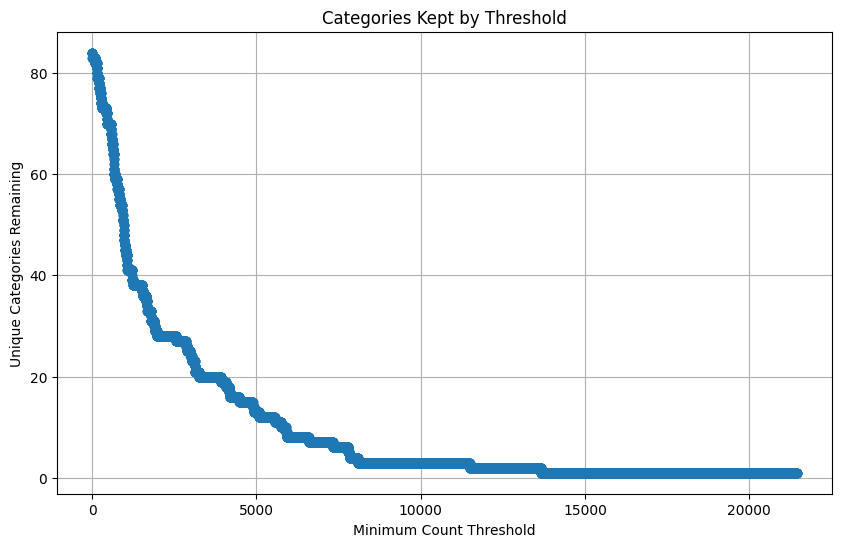

In [16]:
import matplotlib.pyplot as plt

plot_data = threshold_data.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(plot_data["threshold"], plot_data["categories_kept"], marker='o')

plt.title("Categories Kept by Threshold")
plt.xlabel("Minimum Count Threshold")
plt.ylabel("Unique Categories Remaining")
plt.grid(True)
plt.show()

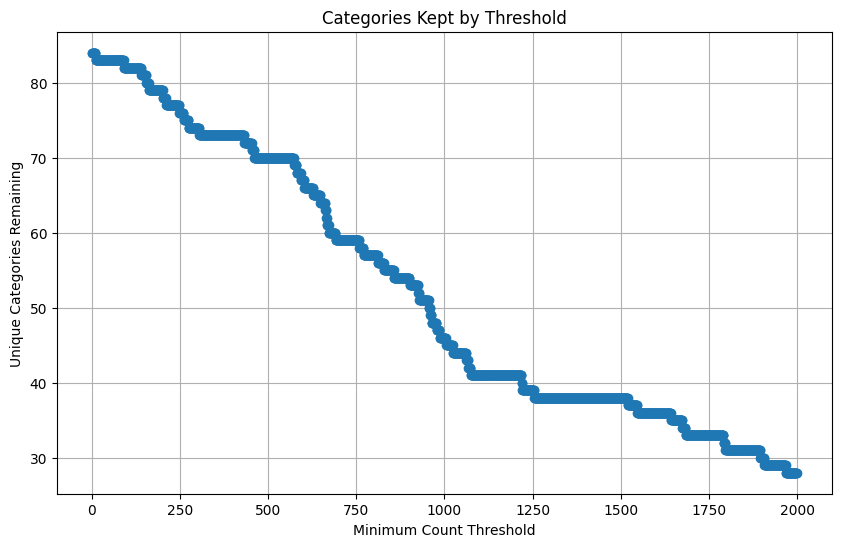

In [18]:
filtered_stats = threshold_data.filter(pl.col("threshold") < 2000)

plot_data = filtered_stats.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(plot_data["threshold"], plot_data["categories_kept"], marker='o')

plt.title("Categories Kept by Threshold")
plt.xlabel("Minimum Count Threshold")
plt.ylabel("Unique Categories Remaining")
plt.grid(True)
plt.show()

It seems to drop drastically until around 1000 games, but reducing the number of categories by half feels too drastic imo.

Let's just look at the 1000 treshold (curiosity).

In [20]:
valid_categories = (
    data.explode("categories")
    .group_by("categories")
    .len()
    .filter(pl.col("len") >= 1000)
    .select("categories")
)

df_clean = (
    data.with_row_index("row_id")
    .explode("categories")        
    .join(
        valid_categories, 
        on="categories", 
        how="inner"           
    )
    .group_by("row_id")       
    .agg(pl.col("categories")) 
    .sort("row_id")           
    .drop("row_id")          
)

print(df_clean)

shape: (86_212, 1)
┌─────────────────────────────────┐
│ categories                      │
│ ---                             │
│ list[str]                       │
╞═════════════════════════════════╡
│ ["Economic", "Negotiation", "P… │
│ ["Card Game", "Fantasy"]        │
│ ["Abstract Strategy", "Medieva… │
│ ["Ancient"]                     │
│ ["Economic", "Territory Buildi… │
│ …                               │
│ ["Deduction"]                   │
│ ["Dice", "Educational", … "Pri… │
│ ["Economic", "Exploration", "N… │
│ ["Bluffing"]                    │
│ ["Card Game"]                   │
└─────────────────────────────────┘


87659 -> 86212

We reduced the number of mechanics almost by half.

Let's now check correlation

In [22]:
df_id = df_clean.with_row_index("game_id")
df_exploded = df_id.explode("categories")
df_matrix = (
    df_exploded
    .pivot(
        on="categories", 
        index="game_id", 
        values="categories", 
        aggregate_function="len"
    )
    .fill_null(0)
)

print(df_matrix.head())

shape: (5, 47)
┌─────────┬──────────┬─────────────┬───────────┬───┬────────┬──────────────┬─────────────┬──────┐
│ game_id ┆ Economic ┆ Negotiation ┆ Political ┆ … ┆ Number ┆ Comic Book / ┆ Educational ┆ Book │
│ ---     ┆ ---      ┆ ---         ┆ ---       ┆   ┆ ---    ┆ Strip        ┆ ---         ┆ ---  │
│ u32     ┆ u32      ┆ u32         ┆ u32       ┆   ┆ u32    ┆ ---          ┆ u32         ┆ u32  │
│         ┆          ┆             ┆           ┆   ┆        ┆ u32          ┆             ┆      │
╞═════════╪══════════╪═════════════╪═══════════╪═══╪════════╪══════════════╪═════════════╪══════╡
│ 0       ┆ 1        ┆ 1           ┆ 1         ┆ … ┆ 0      ┆ 0            ┆ 0           ┆ 0    │
│ 1       ┆ 0        ┆ 0           ┆ 0         ┆ … ┆ 0      ┆ 0            ┆ 0           ┆ 0    │
│ 2       ┆ 0        ┆ 0           ┆ 0         ┆ … ┆ 0      ┆ 0            ┆ 0           ┆ 0    │
│ 3       ┆ 0        ┆ 0           ┆ 0         ┆ … ┆ 0      ┆ 0            ┆ 0           ┆ 0    │
│ 4  

In [23]:
categoy_cols = [col for col in df_matrix.columns if col != "game_id"]

corr_matrix = df_matrix.select(categoy_cols).corr()

print(corr_matrix)

shape: (46, 46)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Economic  ┆ Negotiati ┆ Political ┆ Card Game ┆ … ┆ Number    ┆ Comic     ┆ Education ┆ Book     │
│ ---       ┆ on        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ Book /    ┆ al        ┆ ---      │
│ f64       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ Strip     ┆ ---       ┆ f64      │
│           ┆ f64       ┆           ┆           ┆   ┆           ┆ ---       ┆ f64       ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ 0.458126  ┆ 0.06584   ┆ -0.098559 ┆ … ┆ -0.018974 ┆ -0.017837 ┆ 0.000335  ┆ -0.02875 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 3        │
│ 0.458126  ┆ 1.0       ┆ 0.129639  ┆ -0.054506 ┆ … ┆ -0.016203 ┆ -0.002701

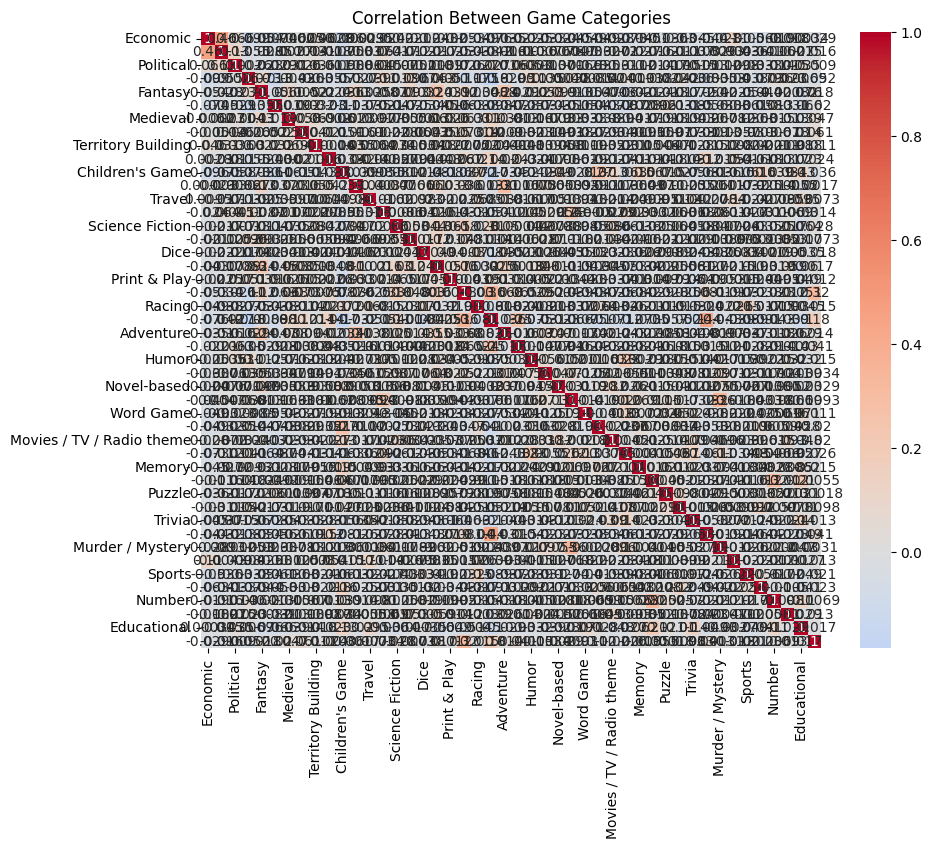

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf_corr = corr_matrix.to_pandas()

pdf_corr.index = pdf_corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(pdf_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Game Categories")
plt.show()

In [25]:
ranked_correlations = (
    corr_matrix
    .with_columns(pl.Series("category_1", categoy_cols))
    .unpivot(
        index=["category_1"], 
        variable_name="category_2", 
        value_name="correlation"
    )
    .filter(pl.col("category_1") < pl.col("category_2"))
    .sort("correlation", descending=True)
)

print(ranked_correlations.head(20))

shape: (20, 3)
┌────────────────────┬──────────────────┬─────────────┐
│ category_1         ┆ category_2       ┆ correlation │
│ ---                ┆ ---              ┆ ---         │
│ str                ┆ str              ┆ f64         │
╞════════════════════╪══════════════════╪═════════════╡
│ Economic           ┆ Negotiation      ┆ 0.458126    │
│ Wargame            ┆ World War II     ┆ 0.437769    │
│ Deduction          ┆ Murder / Mystery ┆ 0.358336    │
│ Miniatures         ┆ Wargame          ┆ 0.356915    │
│ Math               ┆ Number           ┆ 0.317432    │
│ …                  ┆ …                ┆ …           │
│ Book               ┆ Wargame          ┆ 0.176595    │
│ Action / Dexterity ┆ Children's Game  ┆ 0.159602    │
│ Fighting           ┆ Miniatures       ┆ 0.159584    │
│ Children's Game    ┆ Memory           ┆ 0.154789    │
│ Racing             ┆ Sports           ┆ 0.150819    │
└────────────────────┴──────────────────┴─────────────┘


It's too low to merge I think

Let's use hierarchical clustering to try and form clusters of categories.

In [26]:
import scipy.cluster.hierarchy as sch

df_corr_pandas = corr_matrix.to_pandas()
df_corr_pandas.index = categoy_cols
df_corr_pandas.columns = categoy_cols

/tmp/ipykernel_25618/1190085960.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(distance_matrix, method='ward')


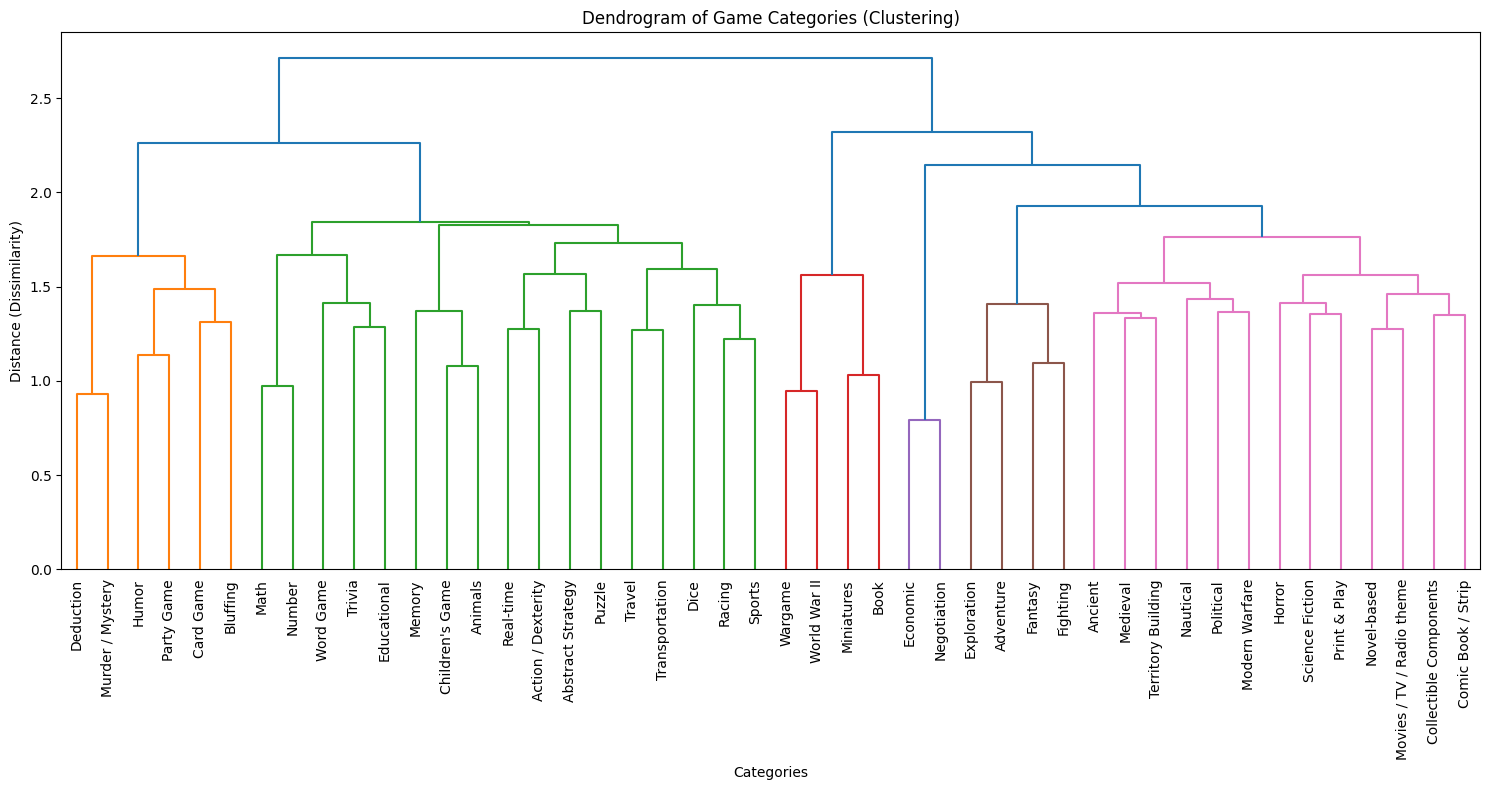

In [27]:
distance_matrix = 1 - df_corr_pandas
linkage_matrix = sch.linkage(distance_matrix, method='ward')

plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(
    linkage_matrix,
    labels=df_corr_pandas.index,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Dendrogram of Game Categories (Clustering)")
plt.xlabel("Categories")
plt.ylabel("Distance (Dissimilarity)")
plt.tight_layout()
plt.show()

In [ ]:
categories_map = {
    # Math + Number
    "Math": "Math & Number",
    "Number": "Math & Number",

    # Trivia + Educational
    "Trivia": "Trivia & Educational",
    "Educational": "Trivia & Educational",

    # Wargame + World War II
    "Wargame": "Wargame & WWII",
    "World War II": "Wargame & WWII",

    # Economic + Negotiation
    "Economic": "Economic & Negotiation",
    "Negotiation": "Economic & Negotiation",

    # Exploration + Adventure
    "Exploration": "Adventure & Exploration",
    "Adventure": "Adventure & Exploration",

    # Novel-based + Movies/TV
    "Novel-based": "Media Theme",
    "Movies / TV / Radio theme": "Media Theme" 
}